# FACED training-domain PSD reference → frequency-resolved JSD → CNN + Transformer

## tl;dr

This notebook is a leakage-safe, tunable experiment scaffold for FACED:

1. fit a **pooled mean PSD reference from source-fit subjects only**;
2. compute a frequency-resolved JSD field while preserving `time × channel × band × native-frequency`;
3. use a 3D CNN for channel/band/frequency structure and a Transformer for temporal structure;
4. select checkpoints with source-validation Macro-F1 and plot a source-validation confusion matrix every 10 epochs;
5. optionally load the outer target subjects only after the checkpoint is locked.

The checked-in execution uses the `smoke` setting and 50 epochs, with source-validation confusion matrices every 10 epochs. It also runs a source-fit single-batch overfit check to distinguish an optimization bug from weak cross-subject signal. Its concrete result is a pipeline check, not an outer-target claim. Change `RUN_MODE` to `"full"` only after choosing a new `RUN_NAME`.

**Checked-in source-only smoke result:** the single-batch loss fell from about 2.20 to 1.63, but the selected source-validation checkpoint reached only 14.29% accuracy / 2.78% Macro-F1 and collapsed mainly to neutral. The outer target was not loaded. This is a useful failure signal for tuning, not evidence of efficacy.

## Context & Methods

### Key assumptions

- Cached FACED native PSDs are normalized inside each physical band and use the native 1-second FFT grids (3/4/6/16/17 points).
- JSD is decomposed pointwise. With `JSD_FIELD="sqrt"`, the tensor contains `sqrt(j(f))`, so `sum_f field(f)^2 = JSD(p,q)` for each channel-band-window.
- The reference, feature normalizer, model, and checkpoint are fitted without outer-target subjects.
- The confusion matrices shown during optimization are **source-validation** matrices. They are safe for tuning; target monitoring during training is intentionally absent.

## Parameters

Edit this cell first. Keep a unique `RUN_NAME` for every material configuration.

In [1]:
# ------------------------------ Protocol ------------------------------
RUN_NAME = "faced_psd_jsd_cnn_transformer_smoke_executed"
RUN_MODE = "smoke"  # "smoke" or "full"
FOLD = 2
SEED = 42
PROTOCOL = "conventional_subject_holdout"  # or "subject_and_stimulus_holdout"
SOURCE_VALIDATION_SUBJECTS = 12
SMOKE_FIT_SUBJECTS = 8
SMOKE_DEV_SUBJECTS = 4
EVALUATE_TARGET_AFTER_LOCK = False

# ------------------------------ Features ------------------------------
JSD_FIELD = "sqrt"  # "sqrt" preserves sum(field^2)=JSD; "raw" stores j(f)
EPSILON = 1e-12
STANDARDIZE_SOURCE_FEATURES = True
FEATURE_STORAGE_DTYPE = "float16"

# ------------------------------- Model --------------------------------
CNN_CHANNELS = (8, 16, 32)
CNN_DROPOUT = 0.10
D_MODEL = 1200
TRANSFORMER_HEADS = 12
TRANSFORMER_LAYERS = 6
TRANSFORMER_FEEDFORWARD = 4800
TRANSFORMER_DROPOUT = 0.15

# ------------------------------ Training ------------------------------
EPOCHS = 50
CONFUSION_EVERY = 10
BATCH_SIZE = 64
EVAL_BATCH_SIZE = 64
LEARNING_RATE = 1e-3
MINIMUM_LEARNING_RATE = 1e-6
WEIGHT_DECAY = 1e-2
LABEL_SMOOTHING = 0.05
GRADIENT_CLIP_NORM = 1.0
PRECISION = "float32"  # start here for small JSD fields; try mixed precision only after stability
DEVICE = "auto"
NUM_WORKERS = 0  # keep zero for deterministic Windows notebook execution
RUN_SINGLE_BATCH_SANITY = True
SANITY_STEPS = 100

## Data

### 1. Setup and deterministic runtime

In [2]:
from __future__ import annotations

import csv
import gc
import hashlib
import json
import math
import random
import sys
import time
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
)
from torch import nn
from torch.utils.data import DataLoader, Dataset


def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src" / "cmrd" / "faced.py").is_file():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the CMRD repository")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

from cmrd.faced import EMOTION_NAMES, SUBJECTS, VIDEO_LABELS, VIDEOS, official_fold_subjects


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(SEED)
device = torch.device("cuda" if DEVICE == "auto" and torch.cuda.is_available() else DEVICE if DEVICE != "auto" else "cpu")
if device.type == "cuda":
    torch.set_float32_matmul_precision("high")

RUN_ROOT = REPO_ROOT / "runs" / RUN_NAME
RUN_ROOT.mkdir(parents=True, exist_ok=True)
print("Repository:", REPO_ROOT)
print("Device:", device)
print("Run output:", RUN_ROOT)

Repository: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting
Device: cuda
Run output: C:\Users\Lin\Documents\Arbitruam\CMRD-Cute-Mew-Really-Delighting\runs\faced_psd_jsd_cnn_transformer_smoke_executed


### 2. Locate and audit the native PSD cache

In [3]:
BASE_RUN_ROOT = REPO_ROOT / "runs" / "faced_native_compact_base_seed42"
manifest_paths = sorted((BASE_RUN_ROOT / "cache" / "native_spectra").glob("*/manifest.json"))
complete_manifests = []
for path in manifest_paths:
    payload = json.loads(path.read_text(encoding="utf-8"))
    if payload.get("all_subjects_complete") and len(payload.get("subjects_complete", [])) == SUBJECTS:
        complete_manifests.append((path, payload))
if len(complete_manifests) != 1:
    raise RuntimeError(f"Expected one complete FACED native PSD cache, found {len(complete_manifests)}")

SPECTRA_MANIFEST_PATH, spectra_manifest = complete_manifests[0]
SPECTRA_ROOT = SPECTRA_MANIFEST_PATH.parent
BAND_NAMES = tuple(spectra_manifest["band_names"])
BAND_SIZES = tuple(map(int, spectra_manifest["band_sizes"]))
FREQUENCY_MAX = max(BAND_SIZES)
FREQUENCY_MASK = np.zeros((len(BAND_NAMES), FREQUENCY_MAX), dtype=np.float32)
for band_index, size in enumerate(BAND_SIZES):
    FREQUENCY_MASK[band_index, :size] = 1.0

audit_frame = pd.DataFrame({"band": BAND_NAMES, "native_frequency_points": BAND_SIZES})
display(audit_frame)
print("Estimator:", spectra_manifest["estimator"])
print("Complete subjects:", len(spectra_manifest["subjects_complete"]))

,band,native_frequency_points
0,delta,3
1,theta,4
2,alpha,6
3,beta,16
4,gamma,17


Estimator: Hann modified periodogram, native 250-point FFT
Complete subjects: 123


### 3. Define source/validation/target and optional video holdout

In [4]:
def stimulus_split():
    train, development, target = [], [], []
    for label in range(len(EMOTION_NAMES)):
        videos = np.flatnonzero(VIDEO_LABELS == label).tolist()
        if len(videos) < 3:
            raise ValueError("Every emotion needs at least three videos for stimulus isolation")
        train.extend(videos[:-2])
        development.append(videos[-2])
        target.append(videos[-1])
    return {
        "train": np.asarray(sorted(train), dtype=np.int64),
        "development": np.asarray(development, dtype=np.int64),
        "target": np.asarray(target, dtype=np.int64),
    }


source_subjects, outer_target_subjects = official_fold_subjects(FOLD)
full_dev_subjects = source_subjects[:SOURCE_VALIDATION_SUBJECTS]
full_fit_subjects = [subject for subject in source_subjects if subject not in set(full_dev_subjects)]

if RUN_MODE == "smoke":
    fit_subjects = full_fit_subjects[:SMOKE_FIT_SUBJECTS]
    dev_subjects = full_dev_subjects[:SMOKE_DEV_SUBJECTS]
elif RUN_MODE == "full":
    fit_subjects = full_fit_subjects
    dev_subjects = full_dev_subjects
else:
    raise ValueError("RUN_MODE must be 'smoke' or 'full'")

if PROTOCOL == "conventional_subject_holdout":
    train_videos = dev_videos = target_videos = np.arange(VIDEOS, dtype=np.int64)
elif PROTOCOL == "subject_and_stimulus_holdout":
    video_split = stimulus_split()
    train_videos, dev_videos, target_videos = (
        video_split["train"], video_split["development"], video_split["target"]
    )
else:
    raise ValueError(PROTOCOL)

assert set(fit_subjects).isdisjoint(dev_subjects)
assert set(fit_subjects).isdisjoint(outer_target_subjects)
assert set(dev_subjects).isdisjoint(outer_target_subjects)

protocol_table = pd.DataFrame({
    "role": ["source fit", "source validation", "outer target (locked)"],
    "subjects": [len(fit_subjects), len(dev_subjects), len(outer_target_subjects)],
    "videos per subject": [len(train_videos), len(dev_videos), len(target_videos)],
})
display(protocol_table)
print("fit subjects:", fit_subjects)
print("development subjects:", dev_subjects)
print("outer target subjects (not loaded during training):", outer_target_subjects)

,role,subjects,videos per subject
0,source fit,8,28
1,source validation,4,28
2,outer target (locked),12,28


fit subjects: [24, 25, 26, 27, 28, 29, 30, 31]
development subjects: [0, 1, 2, 3]
outer target subjects (not loaded during training): [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### 4. Fit the pooled training-domain PSD reference

The averaging pass touches only `fit_subjects × train_videos`. Each channel-band reference is normalized after averaging.

In [5]:
def subject_archive_path(subject: int) -> Path:
    return SPECTRA_ROOT / "subjects" / f"sub{subject:03d}.npz"


def load_subject_psd(subject: int) -> list[np.ndarray]:
    with np.load(subject_archive_path(subject), allow_pickle=False) as archive:
        values = [np.asarray(archive[name], dtype=np.float32) for name in BAND_NAMES]
    for name, value, size in zip(BAND_NAMES, values, BAND_SIZES, strict=True):
        expected = (VIDEOS, 30, 30, size)
        if value.shape != expected or not np.isfinite(value).all():
            raise ValueError(f"sub{subject:03d}/{name}: expected {expected}, got {value.shape}")
        if not np.allclose(value.sum(axis=-1), 1.0, atol=2e-5):
            raise ValueError(f"sub{subject:03d}/{name}: PSD is not band-normalized")
    return values


def fit_training_domain_reference(subjects, videos):
    sums = [np.zeros((30, size), dtype=np.float64) for size in BAND_SIZES]
    windows = 0
    selected_videos = np.asarray(videos, dtype=np.int64)
    for index, subject in enumerate(subjects, 1):
        for band_index, value in enumerate(load_subject_psd(subject)):
            selected = value[selected_videos]  # [video,time,channel,frequency]
            sums[band_index] += selected.sum(axis=(0, 1), dtype=np.float64)
        windows += len(selected_videos) * 30
        if index % 12 == 0 or index == len(subjects):
            print(f"reference pass {index}/{len(subjects)} subjects")
    references = []
    for value in sums:
        reference = value / windows
        reference /= reference.sum(axis=-1, keepdims=True)
        references.append(reference.astype(np.float32))
    return references, windows


reference_started = time.perf_counter()
PSD_REFERENCE, REFERENCE_WINDOWS = fit_training_domain_reference(fit_subjects, train_videos)
reference_seconds = time.perf_counter() - reference_started
assert all(np.allclose(value.sum(axis=-1), 1.0, atol=2e-6) for value in PSD_REFERENCE)
print(f"Reference fitted from {REFERENCE_WINDOWS:,} source-fit windows in {reference_seconds:.2f}s")

reference_provenance = {
    "scope": "source_fit_subjects_and_train_videos_only",
    "fold": FOLD,
    "seed": SEED,
    "protocol": PROTOCOL,
    "fit_subjects": list(map(int, fit_subjects)),
    "train_videos": list(map(int, train_videos)),
    "windows": int(REFERENCE_WINDOWS),
    "band_names": list(BAND_NAMES),
    "band_sizes": list(BAND_SIZES),
}
(RUN_ROOT / "reference_provenance.json").write_text(json.dumps(reference_provenance, indent=2), encoding="utf-8")

reference pass 8/8 subjects
Reference fitted from 6,720 source-fit windows in 0.19s


621

### 5. Transform PSD into a padded channel × band × frequency JSD field

Padding is only for tensor batching; `FREQUENCY_MASK` prevents padded bins from entering the CNN.

In [6]:
def pointwise_jsd_field(p: np.ndarray, q: np.ndarray, mode: str = "sqrt"):
    q = q[None, None, :, :]  # [1,1,channel,frequency]
    midpoint = 0.5 * (p + q)
    contribution = 0.5 * (
        p * (np.log(p + EPSILON) - np.log(midpoint + EPSILON))
        + q * (np.log(q + EPSILON) - np.log(midpoint + EPSILON))
    )
    contribution = np.maximum(contribution, 0.0).astype(np.float32)
    if mode == "sqrt":
        field = np.sqrt(contribution, dtype=np.float32)
        invariant_error = float(np.max(np.abs(np.square(field).sum(axis=-1) - contribution.sum(axis=-1))))
    elif mode == "raw":
        field = contribution
        invariant_error = 0.0
    else:
        raise ValueError("JSD_FIELD must be 'sqrt' or 'raw'")
    return field, invariant_error


def transform_subject(subject: int, videos, reference):
    selected_videos = np.asarray(videos, dtype=np.int64)
    padded = np.zeros(
        (len(selected_videos), 30, 30, len(BAND_NAMES), FREQUENCY_MAX),
        dtype=np.float32,
    )
    maximum_error = 0.0
    for band_index, (psd, q, size) in enumerate(
        zip(load_subject_psd(subject), reference, BAND_SIZES, strict=True)
    ):
        field, error = pointwise_jsd_field(psd[selected_videos], q, JSD_FIELD)
        padded[..., band_index, :size] = field
        maximum_error = max(maximum_error, error)
    labels = VIDEO_LABELS[selected_videos].astype(np.int64)
    return padded, labels, maximum_error


sample_features, sample_labels, sample_invariant_error = transform_subject(
    fit_subjects[0], train_videos, PSD_REFERENCE
)
print("Sample tensor [trial,time,channel,band,frequency]:", sample_features.shape)
print("Maximum sqrt-JSD reconstruction error:", sample_invariant_error)
assert sample_features.shape[2:] == (30, 5, 17)
assert sample_invariant_error < 1e-6
del sample_features, sample_labels
gc.collect()

Sample tensor [trial,time,channel,band,frequency]: (28, 30, 30, 5, 17)
Maximum sqrt-JSD reconstruction error: 5.960464477539063e-08


55

### 6. Materialize source-fit and source-validation tensors

Features are stored as float16 by default to keep the full fold practical; each batch is converted to float32 before normalization and modeling.

In [7]:
def build_split(subjects, videos, role: str):
    features, labels, subject_ids, video_ids = [], [], [], []
    maximum_error = 0.0
    selected_videos = np.asarray(videos, dtype=np.int64)
    started = time.perf_counter()
    storage_dtype = np.float16 if FEATURE_STORAGE_DTYPE == "float16" else np.float32
    for index, subject in enumerate(subjects, 1):
        value, target, error = transform_subject(subject, selected_videos, PSD_REFERENCE)
        features.append(value.astype(storage_dtype))
        labels.append(target)
        subject_ids.extend([int(subject)] * len(selected_videos))
        video_ids.extend(selected_videos.tolist())
        maximum_error = max(maximum_error, error)
        if index % 12 == 0 or index == len(subjects):
            print(f"{role}: {index}/{len(subjects)} subjects")
    output = {
        "x": np.concatenate(features, axis=0),
        "y": np.concatenate(labels),
        "subjects": np.asarray(subject_ids, dtype=np.int64),
        "videos": np.asarray(video_ids, dtype=np.int64),
        "maximum_invariant_error": maximum_error,
        "elapsed_seconds": time.perf_counter() - started,
    }
    print(role, output["x"].shape, output["x"].dtype, f"{output['elapsed_seconds']:.2f}s")
    return output


train_split = build_split(fit_subjects, train_videos, "source_fit")
dev_split = build_split(dev_subjects, dev_videos, "source_validation")


def fit_source_standardizer(values: np.ndarray, chunk_trials: int = 32):
    total = np.zeros(values.shape[2:], dtype=np.float64)
    square = np.zeros_like(total)
    count = 0
    for start in range(0, len(values), chunk_trials):
        chunk = values[start : start + chunk_trials].astype(np.float32)
        total += chunk.sum(axis=(0, 1), dtype=np.float64)
        square += np.square(chunk).sum(axis=(0, 1), dtype=np.float64)
        count += chunk.shape[0] * chunk.shape[1]
    mean = total / count
    variance = np.maximum(square / count - np.square(mean), 0.0)
    std = np.sqrt(variance)
    std[std < 1e-7] = 1.0
    mean *= FREQUENCY_MASK[None, :, :]
    std = np.where(FREQUENCY_MASK[None, :, :] > 0, std, 1.0)
    return mean.astype(np.float32), std.astype(np.float32)


if STANDARDIZE_SOURCE_FEATURES:
    FEATURE_MEAN, FEATURE_STD = fit_source_standardizer(train_split["x"])
else:
    FEATURE_MEAN = np.zeros((30, 5, 17), dtype=np.float32)
    FEATURE_STD = np.ones((30, 5, 17), dtype=np.float32)

print("Finite features:", np.isfinite(train_split["x"]).all(), np.isfinite(dev_split["x"]).all())
print("Class counts (fit):", np.bincount(train_split["y"], minlength=len(EMOTION_NAMES)).tolist())
print("Class counts (dev):", np.bincount(dev_split["y"], minlength=len(EMOTION_NAMES)).tolist())

source_fit: 8/8 subjects
source_fit (224, 30, 30, 5, 17) float16 0.42s
source_validation: 4/4 subjects
source_validation (112, 30, 30, 5, 17) float16 0.24s
Finite features: True True
Class counts (fit): [24, 24, 24, 24, 32, 24, 24, 24, 24]
Class counts (dev): [12, 12, 12, 12, 16, 12, 12, 12, 12]


## Model

### 7. Dataset and CNN + Transformer architecture

In [8]:
class TrialDataset(Dataset):
    def __init__(self, split, mean, std):
        self.x = split["x"]
        self.y = torch.as_tensor(split["y"], dtype=torch.long)
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        value = self.x[index].astype(np.float32)
        value = (value - self.mean) / self.std
        return torch.from_numpy(np.ascontiguousarray(value)), self.y[index]


train_dataset = TrialDataset(train_split, FEATURE_MEAN, FEATURE_STD)
dev_dataset = TrialDataset(dev_split, FEATURE_MEAN, FEATURE_STD)
loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)
dev_loader = DataLoader(
    dev_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)


class CNNTransformer(nn.Module):
    # Conv3d extracts channel×band×frequency structure; Transformer models time.

    def __init__(self):
        super().__init__()
        c1, c2, c3 = CNN_CHANNELS
        self.register_buffer(
            "frequency_mask",
            torch.as_tensor(FREQUENCY_MASK, dtype=torch.float32)[None, None, None, :, :],
            persistent=False,
        )
        self.cnn = nn.Sequential(
            nn.Conv3d(1, c1, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(max(1, c1 // 4), c1),
            nn.GELU(),
            nn.MaxPool3d(kernel_size=(2, 1, 2)),
            nn.Dropout3d(CNN_DROPOUT),
            nn.Conv3d(c1, c2, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(max(1, c2 // 4), c2),
            nn.GELU(),
            nn.MaxPool3d(kernel_size=(2, 1, 2)),
            nn.Dropout3d(CNN_DROPOUT),
            nn.Conv3d(c2, c3, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(max(1, c3 // 4), c3),
            nn.GELU(),
        )
        # After two (2,1,2) pools: channel 30->7, band 5->5, frequency 17->4.
        # Flattening this coarse grid preserves electrode/band/frequency location;
        # global average pooling would erase the identities the CNN should model.
        self.window_projection = nn.Linear(c3 * 7 * 5 * 4, D_MODEL)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, D_MODEL))
        self.position = nn.Parameter(torch.zeros(1, 31, D_MODEL))
        layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=TRANSFORMER_HEADS,
            dim_feedforward=TRANSFORMER_FEEDFORWARD,
            dropout=TRANSFORMER_DROPOUT,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=TRANSFORMER_LAYERS, enable_nested_tensor=False)
        self.classifier = nn.Sequential(
            nn.LayerNorm(D_MODEL),
            nn.Linear(D_MODEL, D_MODEL),
            nn.GELU(),
            nn.Dropout(TRANSFORMER_DROPOUT),
            nn.Linear(D_MODEL, len(EMOTION_NAMES)),
        )
        nn.init.normal_(self.cls_token, std=0.02)
        nn.init.normal_(self.position, std=0.02)

    def encode(self, value):
        # value: [batch,time,channel,band,frequency]
        batch, time_steps = value.shape[:2]
        windows = value.reshape(batch * time_steps, *value.shape[2:]).unsqueeze(1)
        windows = windows * self.frequency_mask.to(windows.dtype)
        tokens = self.cnn(windows).flatten(1)
        tokens = self.window_projection(tokens).reshape(batch, time_steps, D_MODEL)
        cls = self.cls_token.expand(batch, -1, -1)
        sequence = torch.cat([cls, tokens], dim=1)
        sequence = sequence + self.position[:, : time_steps + 1]
        return self.transformer(sequence)[:, 0]

    def forward(self, value):
        return self.classifier(self.encode(value))


model = CNNTransformer().to(device)
parameter_count = sum(parameter.numel() for parameter in model.parameters())
print(model)
print(f"Trainable parameters: {parameter_count:,}")

sample_x, _ = next(iter(train_loader))
with torch.no_grad():
    sample_logits = model(sample_x[:2].to(device))
print("Forward check:", tuple(sample_x[:2].shape), "->", tuple(sample_logits.shape))
assert sample_logits.shape == (2, len(EMOTION_NAMES))

CNNTransformer(
  (cnn): Sequential(
    (0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (1): GroupNorm(2, 8, eps=1e-05, affine=True, bias=True)
    (2): GELU(approximate='none')
    (3): MaxPool3d(kernel_size=(2, 1, 2), stride=(2, 1, 2), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout3d(p=0.1, inplace=False)
    (5): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (6): GroupNorm(4, 16, eps=1e-05, affine=True, bias=True)
    (7): GELU(approximate='none')
    (8): MaxPool3d(kernel_size=(2, 1, 2), stride=(2, 1, 2), padding=0, dilation=1, ceil_mode=False)
    (9): Dropout3d(p=0.1, inplace=False)
    (10): Conv3d(16, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
    (11): GroupNorm(8, 32, eps=1e-05, affine=True, bias=True)
    (12): GELU(approximate='none')
  )
  (window_projection): Linear(in_features=4480, out_features=1200, bias=True)
  (transformer): Transforme

### 8. Source-fit single-batch overfit sanity check

This diagnostic never reads source-validation or target data. A falling loss confirms that gradients and the CNN+Transformer path can fit at least a small source batch. RNG state is restored afterwards so the main run remains reproducible.

In [9]:
if RUN_SINGLE_BATCH_SANITY:
    cpu_rng_state = torch.get_rng_state()
    cuda_rng_states = torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None
    sanity_model = CNNTransformer().to(device)
    sanity_optimizer = torch.optim.AdamW(sanity_model.parameters(), lr=3e-3, weight_decay=0.0)
    sanity_count = min(BATCH_SIZE, len(train_dataset))
    sanity_x = torch.stack([train_dataset[index][0] for index in range(sanity_count)]).to(device)
    sanity_y = torch.stack([train_dataset[index][1] for index in range(sanity_count)]).to(device)
    sanity_losses = []
    for step in range(SANITY_STEPS):
        sanity_model.train()
        sanity_optimizer.zero_grad(set_to_none=True)
        sanity_logits = sanity_model(sanity_x)
        sanity_loss = nn.functional.cross_entropy(sanity_logits, sanity_y)
        sanity_loss.backward()
        nn.utils.clip_grad_norm_(sanity_model.parameters(), GRADIENT_CLIP_NORM)
        sanity_optimizer.step()
        sanity_losses.append(float(sanity_loss.detach()))
    sanity_model.eval()
    with torch.no_grad():
        sanity_accuracy = float((sanity_model(sanity_x).argmax(1) == sanity_y).float().mean())
    print(
        f"single-batch sanity: loss {sanity_losses[0]:.4f} -> {sanity_losses[-1]:.4f}; "
        f"accuracy {sanity_accuracy:.3f}"
    )
    if sanity_losses[-1] >= 0.8 * sanity_losses[0]:
        print("WARNING: the model did not overfit the source batch; inspect architecture/optimization before interpreting metrics.")
    del sanity_model, sanity_optimizer, sanity_x, sanity_y, sanity_logits, sanity_loss
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    torch.set_rng_state(cpu_rng_state)
    if cuda_rng_states is not None:
        torch.cuda.set_rng_state_all(cuda_rng_states)
else:
    sanity_losses = []
    sanity_accuracy = None
    print("Single-batch sanity check disabled.")

single-batch sanity: loss 2.1863 -> 2.1856; accuracy 0.141


## Training

### 9. Evaluation and confusion-matrix helpers

In [10]:
def autocast_context():
    if device.type != "cuda" or PRECISION == "float32":
        return nullcontext()
    dtype = torch.float16 if PRECISION == "float16" else torch.bfloat16
    return torch.autocast(device_type="cuda", dtype=dtype)


@torch.no_grad()
def evaluate_loader(loader):
    model.eval()
    targets, predictions = [], []
    loss_sum, count = 0.0, 0
    for value, label in loader:
        value = value.to(device, non_blocking=True)
        label = label.to(device, non_blocking=True)
        with autocast_context():
            logits = model(value)
            loss = criterion(logits, label)
        batch = label.shape[0]
        loss_sum += float(loss) * batch
        count += batch
        targets.append(label.cpu().numpy())
        predictions.append(logits.argmax(1).cpu().numpy())
    y = np.concatenate(targets)
    prediction = np.concatenate(predictions)
    return {
        "loss": loss_sum / count,
        "accuracy": float(accuracy_score(y, prediction)),
        "balanced_accuracy": float(balanced_accuracy_score(y, prediction)),
        "macro_f1": float(f1_score(y, prediction, average="macro", zero_division=0)),
        "confusion_matrix": confusion_matrix(y, prediction, labels=np.arange(len(EMOTION_NAMES))),
        "targets": y,
        "predictions": prediction,
    }


def plot_confusion(matrix, title: str, output_path: Path | None = None):
    row_sum = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(matrix, row_sum, out=np.zeros_like(matrix, dtype=float), where=row_sum > 0)
    fig, ax = plt.subplots(figsize=(8.5, 7.2))
    image = ax.imshow(normalized, vmin=0, vmax=1, cmap="Blues")
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = normalized[row, column]
            if matrix[row, column] > 0:
                ax.text(column, row, f"{value:.2f}\n({matrix[row,column]})", ha="center", va="center", fontsize=7, color="white" if value > 0.5 else "black")
    ax.set_xticks(range(len(EMOTION_NAMES)), EMOTION_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(len(EMOTION_NAMES)), EMOTION_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Row-normalized recall")
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()


class_counts = np.bincount(train_split["y"], minlength=len(EMOTION_NAMES)).astype(np.float32)
class_weights = class_counts.sum() / (len(class_counts) * np.maximum(class_counts, 1.0))
criterion = nn.CrossEntropyLoss(
    weight=torch.as_tensor(class_weights, dtype=torch.float32, device=device),
    label_smoothing=LABEL_SMOOTHING,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(EPOCHS, 1), eta_min=MINIMUM_LEARNING_RATE
)
use_scaler = device.type == "cuda" and PRECISION == "float16"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=use_scaler)

### 10. Train and display source-validation confusion every 10 epochs

Checkpoint selection uses source-validation Macro-F1 only. The outer target split is not constructed in this cell.

epoch 001/50 | train loss 2.6750 acc 0.0893 | dev BAcc 0.1111 F1 0.0215
epoch 002/50 | train loss 2.9472 acc 0.1250 | dev BAcc 0.1111 F1 0.0215
epoch 003/50 | train loss 3.6103 acc 0.0893 | dev BAcc 0.1111 F1 0.0278
epoch 004/50 | train loss 2.3801 acc 0.1071 | dev BAcc 0.1111 F1 0.0215
epoch 005/50 | train loss 2.3372 acc 0.1161 | dev BAcc 0.1111 F1 0.0215
epoch 006/50 | train loss 2.2526 acc 0.0893 | dev BAcc 0.1111 F1 0.0215
epoch 007/50 | train loss 2.2313 acc 0.0893 | dev BAcc 0.1111 F1 0.0215
epoch 008/50 | train loss 2.2178 acc 0.1116 | dev BAcc 0.1111 F1 0.0215
epoch 009/50 | train loss 2.2333 acc 0.0938 | dev BAcc 0.1111 F1 0.0215
epoch 010/50 | train loss 2.2176 acc 0.0938 | dev BAcc 0.1111 F1 0.0215


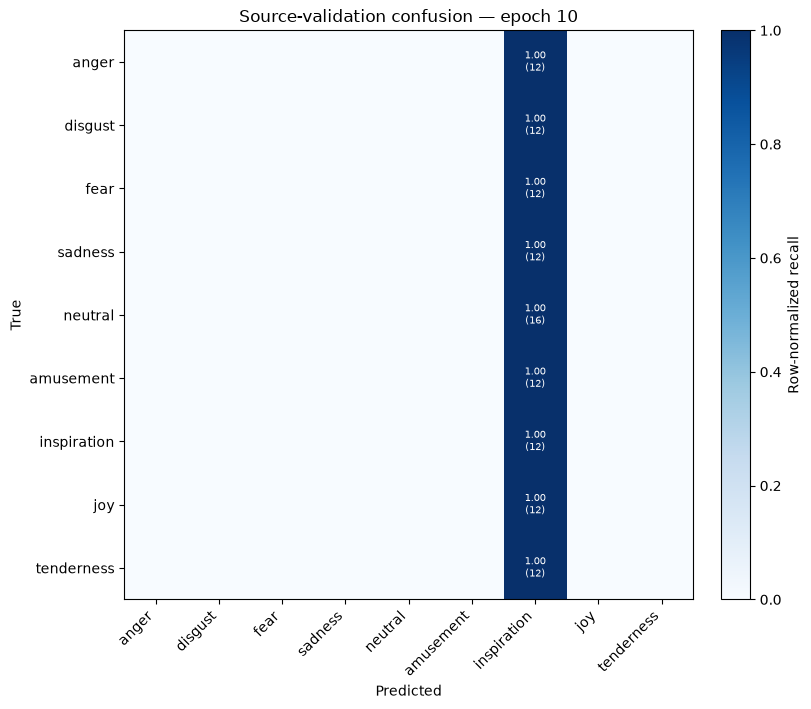

epoch 011/50 | train loss 2.2124 acc 0.0848 | dev BAcc 0.1111 F1 0.0215
epoch 012/50 | train loss 2.2146 acc 0.0759 | dev BAcc 0.1111 F1 0.0215
epoch 013/50 | train loss 2.2171 acc 0.0804 | dev BAcc 0.1111 F1 0.0215
epoch 014/50 | train loss 2.2123 acc 0.1071 | dev BAcc 0.1111 F1 0.0215
epoch 015/50 | train loss 2.2092 acc 0.1161 | dev BAcc 0.1111 F1 0.0215
epoch 016/50 | train loss 2.2082 acc 0.1161 | dev BAcc 0.1111 F1 0.0215
epoch 017/50 | train loss 2.2081 acc 0.1071 | dev BAcc 0.1111 F1 0.0215
epoch 018/50 | train loss 2.2141 acc 0.0938 | dev BAcc 0.1111 F1 0.0278
epoch 019/50 | train loss 2.2020 acc 0.0982 | dev BAcc 0.1111 F1 0.0215
epoch 020/50 | train loss 2.2080 acc 0.0982 | dev BAcc 0.1111 F1 0.0215


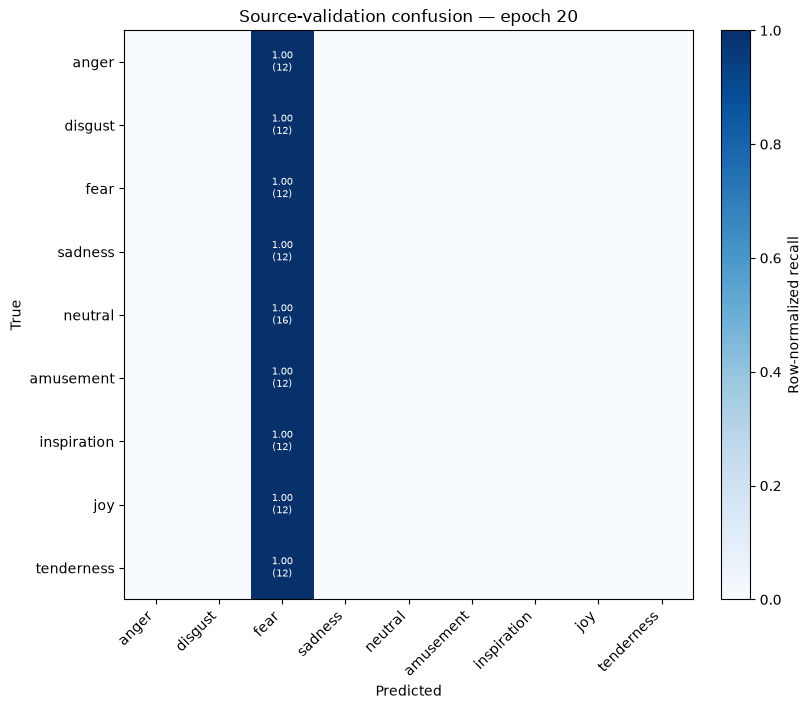

epoch 021/50 | train loss 2.2054 acc 0.1027 | dev BAcc 0.1111 F1 0.0215
epoch 022/50 | train loss 2.2069 acc 0.0938 | dev BAcc 0.1111 F1 0.0215
epoch 023/50 | train loss 2.2051 acc 0.1027 | dev BAcc 0.1111 F1 0.0215
epoch 024/50 | train loss 2.2075 acc 0.0714 | dev BAcc 0.1111 F1 0.0215
epoch 025/50 | train loss 2.2023 acc 0.0848 | dev BAcc 0.1111 F1 0.0215
epoch 026/50 | train loss 2.2146 acc 0.0714 | dev BAcc 0.1111 F1 0.0215
epoch 027/50 | train loss 2.2000 acc 0.1116 | dev BAcc 0.1111 F1 0.0278
epoch 028/50 | train loss 2.1961 acc 0.1830 | dev BAcc 0.1111 F1 0.0278
epoch 029/50 | train loss 2.1981 acc 0.1071 | dev BAcc 0.1111 F1 0.0278
epoch 030/50 | train loss 2.2019 acc 0.1116 | dev BAcc 0.1111 F1 0.0278


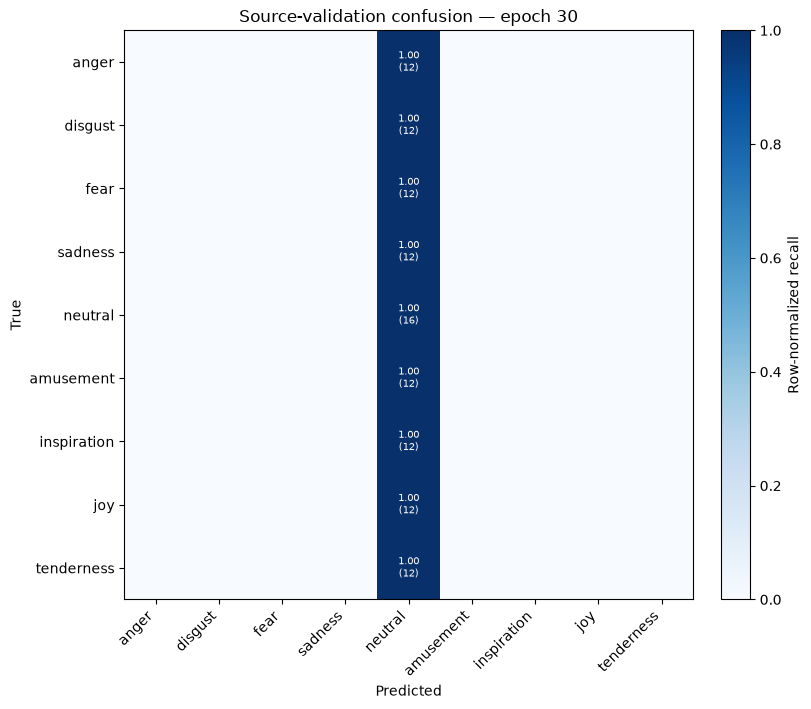

epoch 031/50 | train loss 2.2038 acc 0.1429 | dev BAcc 0.1111 F1 0.0278
epoch 032/50 | train loss 2.2026 acc 0.1339 | dev BAcc 0.1111 F1 0.0215
epoch 033/50 | train loss 2.1985 acc 0.1116 | dev BAcc 0.1111 F1 0.0215
epoch 034/50 | train loss 2.1981 acc 0.1161 | dev BAcc 0.1111 F1 0.0215
epoch 035/50 | train loss 2.1986 acc 0.1295 | dev BAcc 0.1111 F1 0.0215
epoch 036/50 | train loss 2.2024 acc 0.0893 | dev BAcc 0.1111 F1 0.0215
epoch 037/50 | train loss 2.1983 acc 0.1116 | dev BAcc 0.1111 F1 0.0215
epoch 038/50 | train loss 2.1973 acc 0.1027 | dev BAcc 0.1111 F1 0.0215
epoch 039/50 | train loss 2.1971 acc 0.0982 | dev BAcc 0.1111 F1 0.0215
epoch 040/50 | train loss 2.2004 acc 0.1027 | dev BAcc 0.1111 F1 0.0215


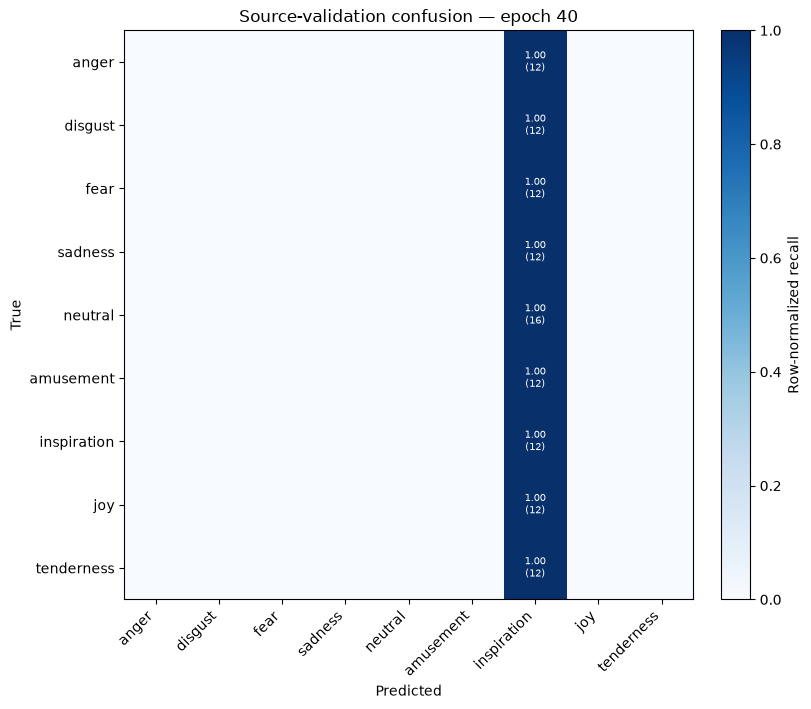

epoch 041/50 | train loss 2.2003 acc 0.0848 | dev BAcc 0.1111 F1 0.0215
epoch 042/50 | train loss 2.1984 acc 0.1250 | dev BAcc 0.1111 F1 0.0215
epoch 043/50 | train loss 2.2024 acc 0.0714 | dev BAcc 0.1111 F1 0.0215
epoch 044/50 | train loss 2.2033 acc 0.1071 | dev BAcc 0.1111 F1 0.0215
epoch 045/50 | train loss 2.1979 acc 0.1116 | dev BAcc 0.1111 F1 0.0215
epoch 046/50 | train loss 2.2012 acc 0.0938 | dev BAcc 0.1111 F1 0.0215
epoch 047/50 | train loss 2.2006 acc 0.1562 | dev BAcc 0.1111 F1 0.0215
epoch 048/50 | train loss 2.1981 acc 0.0982 | dev BAcc 0.1111 F1 0.0215
epoch 049/50 | train loss 2.1974 acc 0.1429 | dev BAcc 0.1111 F1 0.0215
epoch 050/50 | train loss 2.2019 acc 0.0938 | dev BAcc 0.1111 F1 0.0215


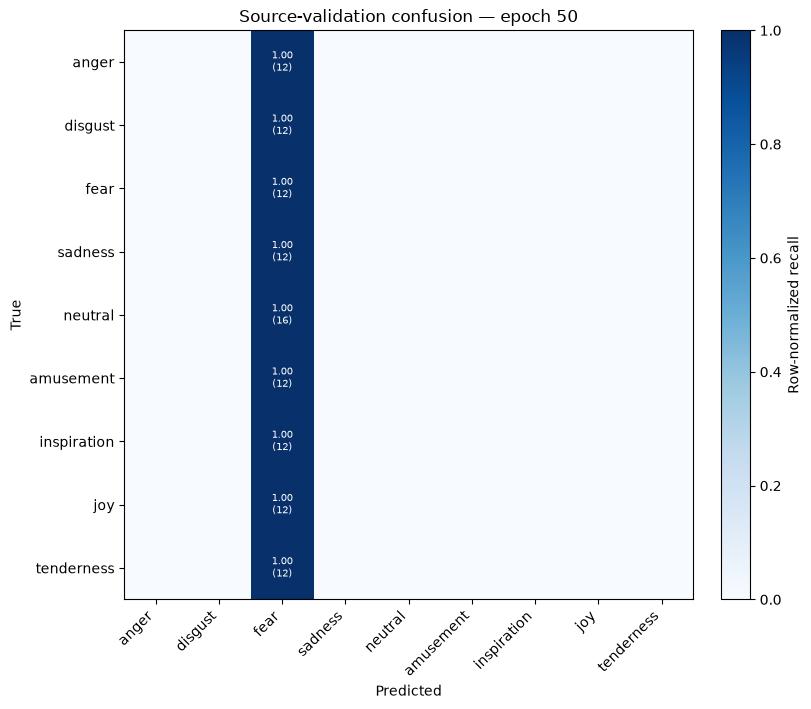

Best source-validation epoch: 3; training time: 32.31s


In [11]:
history = []
best_key = (-math.inf, -math.inf, -math.inf)
best_epoch = 0
checkpoint_path = RUN_ROOT / "source_selected_model.pt"
training_started = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    model.train()
    loss_sum, correct, count = 0.0, 0, 0
    gradient_norms = []
    for value, label in train_loader:
        value = value.to(device, non_blocking=True)
        label = label.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            logits = model(value)
            loss = criterion(logits, label)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        gradient = nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
        scaler.step(optimizer)
        scaler.update()
        batch = label.shape[0]
        loss_sum += float(loss.detach()) * batch
        correct += int((logits.argmax(1) == label).sum())
        count += batch
        gradient_norms.append(float(gradient.detach().cpu()))
    scheduler.step()

    dev_metrics = evaluate_loader(dev_loader)
    row = {
        "epoch": epoch,
        "learning_rate": float(optimizer.param_groups[0]["lr"]),
        "train_loss": loss_sum / count,
        "train_accuracy": correct / count,
        "dev_loss": dev_metrics["loss"],
        "dev_accuracy": dev_metrics["accuracy"],
        "dev_balanced_accuracy": dev_metrics["balanced_accuracy"],
        "dev_macro_f1": dev_metrics["macro_f1"],
        "mean_gradient_norm": float(np.mean(gradient_norms)),
    }
    history.append(row)
    key = (row["dev_macro_f1"], row["dev_balanced_accuracy"], -epoch)
    if key > best_key:
        best_key = key
        best_epoch = epoch
        torch.save({
            "model_state_dict": {name: value.detach().cpu() for name, value in model.state_dict().items()},
            "feature_mean": FEATURE_MEAN,
            "feature_std": FEATURE_STD,
            "psd_reference": PSD_REFERENCE,
            "reference_provenance": reference_provenance,
            "best_epoch": best_epoch,
            "target_loaded_during_training": False,
        }, checkpoint_path)

    print(
        f"epoch {epoch:03d}/{EPOCHS} | train loss {row['train_loss']:.4f} acc {row['train_accuracy']:.4f} | "
        f"dev BAcc {row['dev_balanced_accuracy']:.4f} F1 {row['dev_macro_f1']:.4f}"
    )
    if epoch % CONFUSION_EVERY == 0 or epoch == EPOCHS:
        plot_confusion(
            dev_metrics["confusion_matrix"],
            f"Source-validation confusion — epoch {epoch}",
            RUN_ROOT / f"source_dev_confusion_epoch_{epoch:03d}.png",
        )

training_seconds = time.perf_counter() - training_started
history_frame = pd.DataFrame(history)
history_frame.to_csv(RUN_ROOT / "training_history.csv", index=False)
print(f"Best source-validation epoch: {best_epoch}; training time: {training_seconds:.2f}s")

## Results

### 11. Reload the source-selected checkpoint and summarize development behavior

,epoch,learning_rate,train_loss,train_accuracy,dev_loss,dev_accuracy,dev_balanced_accuracy,dev_macro_f1,mean_gradient_norm
0,1,0.0010,2.6750,0.0893,2.7341,0.1071,0.1111,0.0215,11.4524
1,2,0.0010,2.9472,0.1250,3.8057,0.1071,0.1111,0.0215,16.8639
2,3,0.0010,3.6103,0.0893,2.6253,0.1429,0.1111,0.0278,20.4064
3,4,0.0010,2.3801,0.1071,2.4290,0.1071,0.1111,0.0215,3.0681
4,5,0.0010,2.3372,0.1161,2.2199,0.1071,0.1111,0.0215,2.5891
5,6,0.0010,2.2526,0.0893,2.2141,0.1071,0.1111,0.0215,2.0324
6,7,0.0010,2.2313,0.0893,2.2050,0.1071,0.1111,0.0215,1.8925
7,8,0.0009,2.2178,0.1116,2.2055,0.1071,0.1111,0.0215,1.7865
8,9,0.0009,2.2333,0.0938,2.2080,0.1071,0.1111,0.0215,1.6375
9,10,0.0009,2.2176,0.0938,2.2020,0.1071,0.1111,0.0215,1.6394


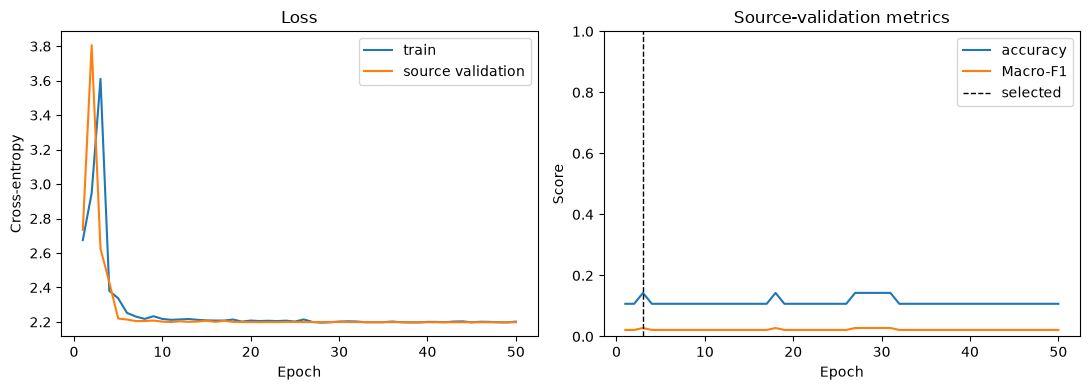

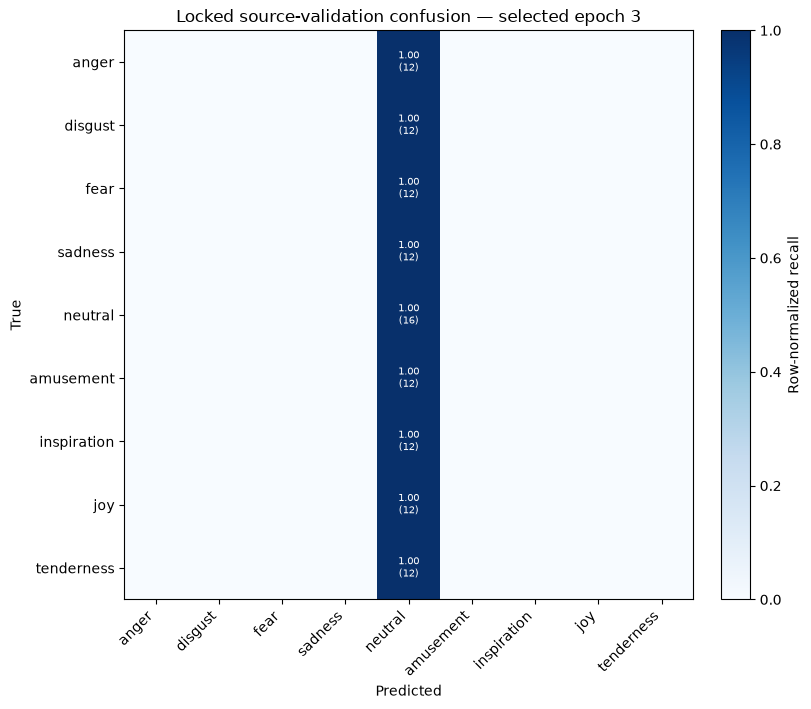

,accuracy,balanced_accuracy,macro_f1
0,0.1429,0.1111,0.0278


In [12]:
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
locked_dev = evaluate_loader(dev_loader)

display(history_frame.round(4))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_frame["epoch"], history_frame["train_loss"], label="train")
axes[0].plot(history_frame["epoch"], history_frame["dev_loss"], label="source validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Cross-entropy")
axes[0].legend()
axes[1].plot(history_frame["epoch"], history_frame["dev_accuracy"], label="accuracy")
axes[1].plot(history_frame["epoch"], history_frame["dev_macro_f1"], label="Macro-F1")
axes[1].axvline(best_epoch, color="black", linestyle="--", linewidth=1, label="selected")
axes[1].set(title="Source-validation metrics", xlabel="Epoch", ylabel="Score", ylim=(0, 1))
axes[1].legend()
fig.tight_layout()
plt.show()

plot_confusion(
    locked_dev["confusion_matrix"],
    f"Locked source-validation confusion — selected epoch {best_epoch}",
    RUN_ROOT / "source_dev_confusion_selected.png",
)

run_summary = {
    "status": "source_checkpoint_locked",
    "run_name": RUN_NAME,
    "run_mode": RUN_MODE,
    "fold": FOLD,
    "seed": SEED,
    "protocol": PROTOCOL,
    "feature": "frequency_resolved_sqrt_jsd_to_source_fit_mean_psd" if JSD_FIELD == "sqrt" else "frequency_resolved_raw_jsd_contribution",
    "tensor_layout": "trial,time,channel,band,padded_native_frequency",
    "tensor_shape_per_trial": list(train_split["x"].shape[1:]),
    "band_names": list(BAND_NAMES),
    "band_sizes": list(BAND_SIZES),
    "reference_fit_scope": reference_provenance["scope"],
    "reference_windows": REFERENCE_WINDOWS,
    "fit_subjects": list(map(int, fit_subjects)),
    "development_subjects": list(map(int, dev_subjects)),
    "outer_target_subjects": list(map(int, outer_target_subjects)),
    "target_loaded_during_training": False,
    "parameter_count": parameter_count,
    "epochs": EPOCHS,
    "best_epoch": best_epoch,
    "source_development": {
        "accuracy": locked_dev["accuracy"],
        "balanced_accuracy": locked_dev["balanced_accuracy"],
        "macro_f1": locked_dev["macro_f1"],
        "confusion_matrix": locked_dev["confusion_matrix"].tolist(),
    },
    "maximum_jsd_invariant_error": max(
        train_split["maximum_invariant_error"], dev_split["maximum_invariant_error"]
    ),
    "training_seconds": training_seconds,
    "single_batch_sanity": {
        "enabled": RUN_SINGLE_BATCH_SANITY,
        "steps": SANITY_STEPS if RUN_SINGLE_BATCH_SANITY else 0,
        "initial_loss": sanity_losses[0] if sanity_losses else None,
        "final_loss": sanity_losses[-1] if sanity_losses else None,
        "accuracy": sanity_accuracy,
    },
}
(RUN_ROOT / "source_locked_summary.json").write_text(json.dumps(run_summary, indent=2), encoding="utf-8")
display(pd.DataFrame([run_summary["source_development"]]).drop(columns="confusion_matrix").round(4))

### 12. Optional outer-target evaluation after lock

Leave `EVALUATE_TARGET_AFTER_LOCK=False` while tuning. Set it to `True` only for a run whose configuration is already frozen. This cell never changes the checkpoint.

In [13]:
if EVALUATE_TARGET_AFTER_LOCK:
    print("Checkpoint is locked. Loading outer target subjects now.")
    target_split = build_split(outer_target_subjects, target_videos, "outer_target_after_lock")
    target_dataset = TrialDataset(target_split, FEATURE_MEAN, FEATURE_STD)
    target_loader = DataLoader(
        target_dataset,
        batch_size=EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
    )
    target_metrics = evaluate_loader(target_loader)
    plot_confusion(
        target_metrics["confusion_matrix"],
        "Outer-target confusion — locked checkpoint",
        RUN_ROOT / "outer_target_confusion_locked.png",
    )
    locked_target = {
        "accuracy": target_metrics["accuracy"],
        "balanced_accuracy": target_metrics["balanced_accuracy"],
        "macro_f1": target_metrics["macro_f1"],
        "confusion_matrix": target_metrics["confusion_matrix"].tolist(),
        "target_used_for_selection": False,
    }
    (RUN_ROOT / "outer_target_locked_result.json").write_text(json.dumps(locked_target, indent=2), encoding="utf-8")
    display(pd.DataFrame([{key: value for key, value in locked_target.items() if key != "confusion_matrix"}]).round(4))
else:
    print("Outer target not loaded. This run remains source-only and safe for tuning.")

Outer target not loaded. This run remains source-only and safe for tuning.


## Takeaways

- Tune architecture and optimization using the source-validation curves and confusion matrices above.
- In the checked-in smoke run, the model could reduce a source-fit single-batch loss but the cross-subject source-validation matrix collapsed. Treat this as evidence that the present pooled-reference unsigned JSD field/training recipe is weak, not as a reason to inspect the outer target.
- Change one parameter group at a time and give each run a unique `RUN_NAME`.
- Useful first sweeps: `(D_MODEL, TRANSFORMER_LAYERS)`, `CNN_CHANNELS`, learning rate, and `JSD_FIELD`.
- Compare models only under the same subject/video protocol and reference scope.
- Do not enable target evaluation repeatedly during tuning. After choosing a configuration, lock it and evaluate on untouched target subjects once.
- A low source-validation score can reflect weak frequency-resolved JSD signal, an underpowered CNN, excessive pooling, or insufficient optimization; inspect the confusion matrix and train/dev gap before adding more modules.